# 1. Import and Install Dependencies

In [1]:
!pip install tensorflow==2.19.0 opencv-python mediapipe==0.10.7 scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\nduha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import mediapipe as mp
import cv2

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF version: 2.19.0
GPU: []


In [3]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic

In [4]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [6]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [7]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [8]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [9]:
draw_landmarks(frame, results)

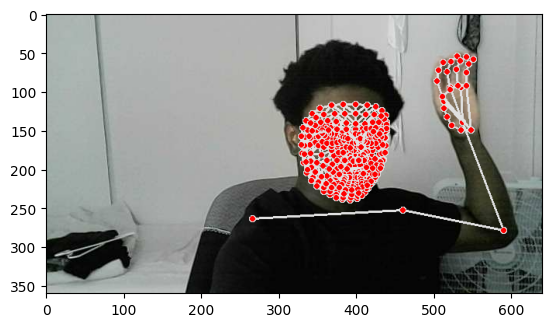

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [11]:
len(results.face_landmarks.landmark)

468

In [12]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [13]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [14]:
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)


In [15]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [16]:
result_test = extract_keypoints(results)

In [17]:
result_test

array([ 0.63471228,  0.47984996, -0.43767524, ...,  0.        ,
        0.        ,  0.        ])

In [18]:
# ============================================
# ENHANCED FEATURE EXTRACTION - POSITION/SCALE INVARIANT
# ============================================

def normalize_keypoints_enhanced(results):
    """
    Extract keypoints that are invariant to:
    - Hand position (relative to body)
    - Distance from camera (normalized by shoulder width)
    - Body orientation (relative to shoulders)
    
    Returns feature vector focused on HAND SHAPE only, not WHERE the hand is
    """
    features = []
    
    # ----- POSE FEATURES (for normalization reference) -----
    if results.pose_landmarks:
        pose = np.array([[lm.x, lm.y, lm.z, lm.visibility] 
                        for lm in results.pose_landmarks.landmark])
        
        # Get key body landmarks for normalization
        left_shoulder = pose[11][:3]  # x,y,z
        right_shoulder = pose[12][:3]
        left_hip = pose[23][:3]
        right_hip = pose[24][:3]
        nose = pose[0][:3]
        
        # Calculate body center and scale
        shoulder_center = (left_shoulder + right_shoulder) / 2
        shoulder_width = np.linalg.norm(left_shoulder - right_shoulder)
        hip_center = (left_hip + right_hip) / 2
        torso_height = np.linalg.norm(shoulder_center - hip_center)
        
        # Use shoulder width as primary scale factor (distance invariant)
        if shoulder_width > 0:
            scale_factor = shoulder_width
        elif torso_height > 0:
            scale_factor = torso_height
        else:
            scale_factor = 1.0
            
        # Add body orientation features (optional)
        body_direction = right_shoulder - left_shoulder
        body_direction = body_direction / (np.linalg.norm(body_direction) + 1e-6)
        features.extend(body_direction[:2])  # x,y direction only
        
    else:
        # No pose detected - use default values
        scale_factor = 1.0
        shoulder_center = np.array([0, 0, 0])
        features.extend([0, 0])  # default body direction
    
    # ----- LEFT HAND FEATURES (position-invariant) -----
    if results.left_hand_landmarks:
        left_hand = np.array([[lm.x, lm.y, lm.z] 
                            for lm in results.left_hand_landmarks.landmark])
        
        # 1. CENTER: Relative to shoulder center (position invariant)
        if 'shoulder_center' in locals():
            left_hand_centered = left_hand - shoulder_center
        else:
            left_hand_centered = left_hand - left_hand[0]  # center relative to wrist
        
        # 2. SCALE: Normalize by shoulder width (distance invariant)
        left_hand_normalized = left_hand_centered / (scale_factor + 1e-6)
        
        # 3. HAND SHAPE FEATURES (what actually matters!)
        # Flatten normalized coordinates
        features.extend(left_hand_normalized.flatten())
        
        # 4. FINGER ANGLE FEATURES (rotation invariant)
        # Index finger (landmarks 5-8)
        if len(left_hand) > 8:
            index_base = left_hand_normalized[5]
            index_tip = left_hand_normalized[8]
            index_vector = index_tip - index_base
            index_angle = np.arctan2(index_vector[1], index_vector[0])
            features.extend([np.sin(index_angle), np.cos(index_angle)])
        
        # Middle finger (landmarks 9-12)
        if len(left_hand) > 12:
            middle_base = left_hand_normalized[9]
            middle_tip = left_hand_normalized[12]
            middle_vector = middle_tip - middle_base
            middle_angle = np.arctan2(middle_vector[1], middle_vector[0])
            features.extend([np.sin(middle_angle), np.cos(middle_angle)])
        
        # Ring finger (landmarks 13-16)
        if len(left_hand) > 16:
            ring_base = left_hand_normalized[13]
            ring_tip = left_hand_normalized[16]
            ring_vector = ring_tip - ring_base
            ring_angle = np.arctan2(ring_vector[1], ring_vector[0])
            features.extend([np.sin(ring_angle), np.cos(ring_angle)])
        
        # Pinky finger (landmarks 17-20)
        if len(left_hand) > 20:
            pinky_base = left_hand_normalized[17]
            pinky_tip = left_hand_normalized[20]
            pinky_vector = pinky_tip - pinky_base
            pinky_angle = np.arctan2(pinky_vector[1], pinky_vector[0])
            features.extend([np.sin(pinky_angle), np.cos(pinky_angle)])
        
        # Thumb (landmarks 1-4) - special because it's different
        if len(left_hand) > 4:
            thumb_base = left_hand_normalized[1]
            thumb_tip = left_hand_normalized[4]
            thumb_vector = thumb_tip - thumb_base
            thumb_angle = np.arctan2(thumb_vector[1], thumb_vector[0])
            features.extend([np.sin(thumb_angle), np.cos(thumb_angle)])
        
        # 5. FINGER TIP DISTANCES (relative to each other)
        # Distance between index and middle tips
        if len(left_hand) > 12:
            dist_idx_mid = np.linalg.norm(left_hand_normalized[8] - left_hand_normalized[12])
            features.append(dist_idx_mid)
        
        # Distance between middle and ring tips
        if len(left_hand) > 16:
            dist_mid_ring = np.linalg.norm(left_hand_normalized[12] - left_hand_normalized[16])
            features.append(dist_mid_ring)
        
        # Distance between ring and pinky tips
        if len(left_hand) > 20:
            dist_ring_pinky = np.linalg.norm(left_hand_normalized[16] - left_hand_normalized[20])
            features.append(dist_ring_pinky)
        
        # 6. HAND OPENNESS (spread of fingers)
        if len(left_hand) > 20:
            palm_center = np.mean(left_hand_normalized[0:5], axis=0)  # wrist area
            tip_positions = left_hand_normalized[[4, 8, 12, 16, 20]]  # all fingertips
            distances_to_palm = [np.linalg.norm(tip - palm_center) for tip in tip_positions]
            features.extend(distances_to_palm)
            features.append(np.mean(distances_to_palm))  # average spread
    else:
        # No left hand - add zeros
        features.extend(np.zeros(21*3))  # positions
        features.extend(np.zeros(5*2))    # finger angles (5 fingers × sin/cos)
        features.extend(np.zeros(3))       # inter-finger distances
        features.extend(np.zeros(6))       # tip distances + avg spread
    
    # ----- RIGHT HAND FEATURES (same as left hand) -----
    if results.right_hand_landmarks:
        right_hand = np.array([[lm.x, lm.y, lm.z] 
                             for lm in results.right_hand_landmarks.landmark])
        
        # 1. CENTER: Relative to shoulder center
        if 'shoulder_center' in locals():
            right_hand_centered = right_hand - shoulder_center
        else:
            right_hand_centered = right_hand - right_hand[0]
        
        # 2. SCALE: Normalize by shoulder width
        right_hand_normalized = right_hand_centered / (scale_factor + 1e-6)
        
        # 3. HAND SHAPE FEATURES
        features.extend(right_hand_normalized.flatten())
        
        # 4. FINGER ANGLE FEATURES
        # Index finger
        if len(right_hand) > 8:
            index_vector = right_hand_normalized[8] - right_hand_normalized[5]
            index_angle = np.arctan2(index_vector[1], index_vector[0])
            features.extend([np.sin(index_angle), np.cos(index_angle)])
        
        # Middle finger
        if len(right_hand) > 12:
            middle_vector = right_hand_normalized[12] - right_hand_normalized[9]
            middle_angle = np.arctan2(middle_vector[1], middle_vector[0])
            features.extend([np.sin(middle_angle), np.cos(middle_angle)])
        
        # Ring finger
        if len(right_hand) > 16:
            ring_vector = right_hand_normalized[16] - right_hand_normalized[13]
            ring_angle = np.arctan2(ring_vector[1], ring_vector[0])
            features.extend([np.sin(ring_angle), np.cos(ring_angle)])
        
        # Pinky finger
        if len(right_hand) > 20:
            pinky_vector = right_hand_normalized[20] - right_hand_normalized[17]
            pinky_angle = np.arctan2(pinky_vector[1], pinky_vector[0])
            features.extend([np.sin(pinky_angle), np.cos(pinky_angle)])
        
        # Thumb
        if len(right_hand) > 4:
            thumb_vector = right_hand_normalized[4] - right_hand_normalized[1]
            thumb_angle = np.arctan2(thumb_vector[1], thumb_vector[0])
            features.extend([np.sin(thumb_angle), np.cos(thumb_angle)])
        
        # 5. FINGER TIP DISTANCES
        if len(right_hand) > 12:
            dist_idx_mid = np.linalg.norm(right_hand_normalized[8] - right_hand_normalized[12])
            features.append(dist_idx_mid)
        
        if len(right_hand) > 16:
            dist_mid_ring = np.linalg.norm(right_hand_normalized[12] - right_hand_normalized[16])
            features.append(dist_mid_ring)
        
        if len(right_hand) > 20:
            dist_ring_pinky = np.linalg.norm(right_hand_normalized[16] - right_hand_normalized[20])
            features.append(dist_ring_pinky)
        
        # 6. HAND OPENNESS
        if len(right_hand) > 20:
            palm_center = np.mean(right_hand_normalized[0:5], axis=0)
            tip_positions = right_hand_normalized[[4, 8, 12, 16, 20]]
            distances_to_palm = [np.linalg.norm(tip - palm_center) for tip in tip_positions]
            features.extend(distances_to_palm)
            features.append(np.mean(distances_to_palm))
    else:
        # No right hand - add zeros
        features.extend(np.zeros(21*3))
        features.extend(np.zeros(5*2))
        features.extend(np.zeros(3))
        features.extend(np.zeros(6))
    
    return np.array(features)


# ============================================
# SIMPLIFIED VERSION - EASIER TO START WITH
# ============================================

def normalize_keypoints_simple(results):
    """
    Simplified version - just center and scale the hand positions
    Much easier to retrain with, still improves distance/position invariance
    """
    features = []
    
    # Get pose for normalization reference
    if results.pose_landmarks:
        pose = np.array([[lm.x, lm.y, lm.z] 
                        for lm in results.pose_landmarks.landmark])
        left_shoulder = pose[11]
        right_shoulder = pose[12]
        shoulder_center = (left_shoulder + right_shoulder) / 2
        shoulder_width = np.linalg.norm(left_shoulder - right_shoulder)
        scale = shoulder_width if shoulder_width > 0 else 1.0
    else:
        shoulder_center = np.array([0, 0, 0])
        scale = 1.0
    
    # Process left hand
    if results.left_hand_landmarks:
        lh = np.array([[lm.x, lm.y, lm.z] 
                      for lm in results.left_hand_landmarks.landmark])
        # Center and scale
        lh = (lh - shoulder_center) / scale
        features.extend(lh.flatten())
    else:
        features.extend(np.zeros(21*3))
    
    # Process right hand
    if results.right_hand_landmarks:
        rh = np.array([[lm.x, lm.y, lm.z] 
                      for lm in results.right_hand_landmarks.landmark])
        # Center and scale
        rh = (rh - shoulder_center) / scale
        features.extend(rh.flatten())
    else:
        features.extend(np.zeros(21*3))
    
    return np.array(features)


# ============================================
# UPDATE YOUR EXTRACTION FUNCTION
# ============================================

def extract_keypoints_invariant(results, method='enhanced'):
    """
    Unified function to extract position-invariant keypoints
    method: 'enhanced' - full features (finger angles, distances)
            'simple'   - just centered/scaled coordinates
            'original' - original MediaPipe coordinates (no normalization)
    """
    if method == 'enhanced':
        return normalize_keypoints_enhanced(results)
    elif method == 'simple':
        return normalize_keypoints_simple(results)
    else:  # original
        pose = np.array([[res.x, res.y, res.z, res.visibility] 
                        for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
        face = np.array([[res.x, res.y, res.z] 
                        for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
        lh = np.array([[res.x, res.y, res.z] 
                      for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
        rh = np.array([[res.x, res.y, res.z] 
                      for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
        return np.concatenate([pose, face, lh, rh])

In [19]:
## ============================================
## DYNAMIC ASL FEATURE EXTRACTION (ADD THIS IN A NEW CELL)
## ============================================
#
## Global variable to store previous hand positions for velocity calculation
## Cell: Dynamic Feature Extraction (Fixed Version)
## Add this global variable for tracking previous frame
#prev_hand_positions = None
#prev_results_store = None  # Store full previous results
#
#def extract_keypoints_dynamic(results):
#    """
#    Returns BOTH static and dynamic features separately
#    You can choose which to use
#    """
#    global prev_hand_positions, prev_results_store
#    
#    # Get your original features (static hand shape) - KEEP THIS EXACTLY AS BEFORE
#    pose = np.array([[res.x, res.y, res.z, res.visibility] 
#                    for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
#    face = np.array([[res.x, res.y, res.z] 
#                    for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
#    lh = np.array([[res.x, res.y, res.z] 
#                  for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
#    rh = np.array([[res.x, res.y, res.z] 
#                  for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
#    
#    # Combine static features (EXACTLY 1662 dimensions)
#    static_features = np.concatenate([pose, face, lh, rh])
#    
#    # Calculate velocity (dynamic features)
#    current_hand_positions = []
#    
#    # Left hand center
#    if results.left_hand_landmarks:
#        lh_points = np.array([[lm.x, lm.y, lm.z] 
#                             for lm in results.left_hand_landmarks.landmark])
#        current_hand_positions.append(np.mean(lh_points, axis=0))
#    else:
#        current_hand_positions.append(np.zeros(3))
#    
#    # Right hand center
#    if results.right_hand_landmarks:
#        rh_points = np.array([[lm.x, lm.y, lm.z] 
#                             for lm in results.right_hand_landmarks.landmark])
#        current_hand_positions.append(np.mean(rh_points, axis=0))
#    else:
#        current_hand_positions.append(np.zeros(3))
#    
#    current_hand_positions = np.array(current_hand_positions).flatten()
#    
#    # Calculate velocity
#    if prev_hand_positions is not None:
#        velocity = current_hand_positions - prev_hand_positions
#    else:
#        velocity = np.zeros(6)
#    
#    # Update for next frame
#    prev_hand_positions = current_hand_positions.copy()
#    prev_results_store = results
#    
#    # Return BOTH - but model only uses static for now
#    return {
#        'static': static_features,  # 1662 dim - USE THIS FOR YOUR CURRENT MODEL
#        'dynamic': velocity,         # 6 dim - for future model
#        'combined': np.concatenate([static_features, velocity])  # 1668 dim
#    }
#
#

In [20]:
#np.save('0', result_test)

In [21]:
#np.load('0.npy')

# 4. Setup Folders for Collection

In [22]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'thanks', 'iloveyou', 
           '0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
           'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 
           'U', 'V', 'W', 'X', 'Y', 'Z'])


# Sixty videos worth of data
no_sequences = 60

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [23]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [24]:
#for action in actions: 
#    dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int))
#    for sequence in range(1,no_sequences+1):
#        try: 
#            os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
#        except:
#            pass

# 5. Collect Keypoint Values for Training and Testing

In [262]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # Add pause and skip state variables
    paused = False
    skip_action = False
    
    print(f"Starting collection for {len(actions)} actions: {', '.join(actions)}")
    print(f"Each action will have {no_sequences} sequences of {sequence_length} frames")
    
    # NEW LOOP - Loop through all 13 actions
    for action in actions:
        # Reset skip flag for each new action
        skip_action = False
        
        # ALWAYS show prompt before each action (regardless of existing data)
        print(f"\n{'='*50}")
        print(f"NEXT ACTION: {action}")
        print(f"{'='*50}")
        
        # Check existing data count for this action
        existing_sequences = 0
        action_path = os.path.join(DATA_PATH, action)
        if os.path.exists(action_path):
            for item in os.listdir(action_path):
                item_path = os.path.join(action_path, item)
                if os.path.isdir(item_path) and item.isdigit():
                    frame_count = len([f for f in os.listdir(item_path) if f.endswith('.npy')])
                    if frame_count > 0:
                        existing_sequences += 1
        
        # Show action selection prompt (ALWAYS appears)
        while True:
            ret, frame = cap.read()
            
            # Display action info
            cv2.putText(frame, f"NEXT ACTION: {action}", (50, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 3, cv2.LINE_AA)
            
            # Show existing data status
            if existing_sequences > 0:
                status_text = f"Has {existing_sequences}/{no_sequences} sequences"
                status_color = (0, 255, 255)  # Yellow
            else:
                status_text = "No existing data"
                status_color = (255, 255, 255)  # White
            
            cv2.putText(frame, status_text, (50, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2, cv2.LINE_AA)
            
            # Show options
            y_offset = 150
            
            # Always show 'c' (Continue)
            cv2.putText(frame, "Press 'c' to CONTINUE collecting", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
            y_offset += 50
            
            # ALWAYS show 'o' (Overwrite) if there's ANY data (even partial)
            if existing_sequences > 0:
                cv2.putText(frame, "Press 'o' to OVERWRITE (delete all and start fresh)", (50, y_offset),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 165, 0), 2, cv2.LINE_AA)  # Orange
                y_offset += 50
            
            # Always show 's' (Skip)
            cv2.putText(frame, "Press 's' to SKIP to next action", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)
            y_offset += 50
            
            # Always show 'q' (Quit)
            cv2.putText(frame, "Press 'q' to QUIT", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
            
            cv2.imshow('OpenCV Feed', frame)
            
            key = cv2.waitKey(10) & 0xFF
            
            if key == ord('c'):  # Continue collecting (resume where left off)
                print(f"Continuing with action '{action}'...")
                if existing_sequences > 0:
                    print(f"Will resume from sequence {existing_sequences}/{no_sequences}")
                break
            
            elif key == ord('o') and existing_sequences > 0:  # Overwrite if ANY data exists
                print(f"OVERWRITING existing data for '{action}'...")
                # DELETE existing data for this action
                import shutil
                if os.path.exists(action_path):
                    shutil.rmtree(action_path)
                    print(f"Deleted all data for '{action}'")
                # Recreate empty folder
                os.makedirs(action_path, exist_ok=True)
                existing_sequences = 0  # Reset count
                break
            
            elif key == ord('s'):  # Skip action
                skip_action = True
                print(f"Skipping action '{action}'")
                break
            
            elif key == ord('q'):  # Quit
                print("Quitting collection...")
                cap.release()
                cv2.destroyAllWindows()
                exit()
        
        if skip_action:
            print(f"\n--- Skipped action: {action} ---")
            continue  # Skip to next action
        
        print(f"\n{'='*50}")
        print(f"STARTING COLLECTION FOR ACTION: {action}")
        print(f"{'='*50}")
        
        # Loop through sequences 0 to (no_sequences-1)
        for sequence in range(no_sequences):
            # Get sequence path
            seq_path = os.path.join(DATA_PATH, action, str(sequence))
            
            # If we're continuing and sequence is already complete, skip it
            if existing_sequences > 0 and os.path.exists(seq_path):
                existing_frames = len([f for f in os.listdir(seq_path) if f.endswith('.npy')])
                if existing_frames >= sequence_length:
                    print(f"Sequence {sequence} already complete. Skipping...")
                    continue
            
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):
                # Skip frame if already exists (when resuming)
                frame_path = os.path.join(DATA_PATH, action, str(sequence), f"{frame_num}.npy")
                if os.path.exists(frame_path):
                    continue
                
                # Read feed
                ret, frame = cap.read()
                if not ret:
                    print("Failed to grab frame")
                    break
                
                # Display pause message if paused
                if paused:
                    cv2.putText(frame, 'PAUSED - Press P to Resume', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 4, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', frame)
                    
                    # Wait for key press while paused
                    key = cv2.waitKey(10) & 0xFF
                    if key == ord('p'):  # Resume if 'p' pressed
                        paused = False
                        print("Resuming collection...")
                        continue
                    elif key == ord('q'):  # Quit if 'q' pressed
                        print("Quitting collection...")
                        cap.release()
                        cv2.destroyAllWindows()
                        exit()
                    else:
                        continue

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # Show action name on screen
                cv2.putText(image, f'ACTION: {action}', (15, 12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.putText(image, f'Sequence: {sequence}/{no_sequences-1}', (15, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
                cv2.putText(image, f'Frame: {frame_num+1}/{sequence_length}', (15, 48), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
                
                # NEW Apply wait logic for first frame
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints (only if not paused)
                # Use position-invariant features for training
                keypoints = extract_keypoints_invariant(results, method='enhanced')  # Start with 'simple', try 'enhanced' later
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                
                # Ensure directory exists before saving
                os.makedirs(os.path.dirname(npy_path), exist_ok=True)
                np.save(npy_path, keypoints)
                
                # Progress indicator (less verbose)
                if frame_num == 0 or frame_num == sequence_length-1 or frame_num % 10 == 0:
                    print(f"  Action: {action}, Seq: {sequence}, Frame: {frame_num+1}/{sequence_length}")

                # Check for pause/quit/skip keys
                key = cv2.waitKey(10) & 0xFF
                if key == ord('p'):  # Pause if 'p' pressed
                    paused = True
                    print("Paused collection. Press P to resume.")
                    frame_num -= 1  # Stay on same frame number
                    continue
                elif key == ord('s'):  # Skip current action if 's' pressed
                    print(f"\nSkipping action '{action}'...")
                    skip_action = True
                    break  # Break out of sequence loop
                elif key == ord('q'):  # Quit if 'q' pressed
                    print("Quitting collection...")
                    cap.release()
                    cv2.destroyAllWindows()
                    exit()
            
            # If skip_action is True, break out of sequence loop
            if skip_action:
                break
        
        print(f"\n✓ Completed action: {action}")
        print(f"Progress: {actions.tolist().index(action) + 1}/{len(actions)} actions done")
                    
    cap.release()
    cv2.destroyAllWindows()
    print("\n" + "="*50)
    print("ALL ACTIONS COLLECTION COMPLETE!")
    print(f"Collected data for {len(actions)} actions:")
    for action in actions:
        action_path = os.path.join(DATA_PATH, action)
        if os.path.exists(action_path):
            seq_count = len([d for d in os.listdir(action_path) 
                           if os.path.isdir(os.path.join(action_path, d)) and d.isdigit()])
            print(f"  - {action}: {seq_count}/{no_sequences} sequences")
    print("="*50)

Starting collection for 39 actions: hello, thanks, iloveyou, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z
Each action will have 60 sequences of 30 frames

NEXT ACTION: hello
Skipping action 'hello'

--- Skipped action: hello ---

NEXT ACTION: thanks
Skipping action 'thanks'

--- Skipped action: thanks ---

NEXT ACTION: iloveyou
Skipping action 'iloveyou'

--- Skipped action: iloveyou ---

NEXT ACTION: 0
Skipping action '0'

--- Skipped action: 0 ---

NEXT ACTION: 1
Skipping action '1'

--- Skipped action: 1 ---

NEXT ACTION: 2
Skipping action '2'

--- Skipped action: 2 ---

NEXT ACTION: 3
Skipping action '3'

--- Skipped action: 3 ---

NEXT ACTION: 4
Skipping action '4'

--- Skipped action: 4 ---

NEXT ACTION: 5
Skipping action '5'

--- Skipped action: 5 ---

NEXT ACTION: 6
Skipping action '6'

--- Skipped action: 6 ---

NEXT ACTION: 7
Skipping action '7'

--- Skipped action: 7 ---

NEXT ACTION: 8
Skipping action '8'

--- Sk

In [263]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [264]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [265]:
label_map = {label:num for num, label in enumerate(actions)}

In [266]:
label_map

{np.str_('hello'): 0,
 np.str_('thanks'): 1,
 np.str_('iloveyou'): 2,
 np.str_('0'): 3,
 np.str_('1'): 4,
 np.str_('2'): 5,
 np.str_('3'): 6,
 np.str_('4'): 7,
 np.str_('5'): 8,
 np.str_('6'): 9,
 np.str_('7'): 10,
 np.str_('8'): 11,
 np.str_('9'): 12,
 np.str_('A'): 13,
 np.str_('B'): 14,
 np.str_('C'): 15,
 np.str_('D'): 16,
 np.str_('E'): 17,
 np.str_('F'): 18,
 np.str_('G'): 19,
 np.str_('H'): 20,
 np.str_('I'): 21,
 np.str_('J'): 22,
 np.str_('K'): 23,
 np.str_('L'): 24,
 np.str_('M'): 25,
 np.str_('N'): 26,
 np.str_('O'): 27,
 np.str_('P'): 28,
 np.str_('Q'): 29,
 np.str_('R'): 30,
 np.str_('S'): 31,
 np.str_('T'): 32,
 np.str_('U'): 33,
 np.str_('V'): 34,
 np.str_('W'): 35,
 np.str_('X'): 36,
 np.str_('Y'): 37,
 np.str_('Z'): 38}

In [267]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [268]:
np.array(sequences).shape

(2340, 30, 166)

In [269]:
np.array(labels).shape

(2340,)

In [270]:
X = np.array(sequences)

In [271]:
X.shape

(2340, 30, 166)

In [272]:
y = to_categorical(labels).astype(int)

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [274]:
y_test.shape

(117, 39)

In [275]:
# ============================================
# FIXED DATA AUGMENTATION - CORRECT FOR 166 FEATURES
# ============================================

import numpy as np
import random
from sklearn.model_selection import train_test_split

def get_feature_structure_166():
    """
    Analyze your 166-feature structure
    Based on your output: 166 features total
    """
    print("Your feature structure (166 total):")
    
    # Let's deduce the structure from the numbers
    # You have 33 pose landmarks × 4 = 132
    # Remaining 34 features (166-132=34) must be hands?
    # But 21×3=63, so maybe no face and just one hand?
    
    pose_features = 33 * 4  # 132
    remaining = 166 - pose_features  # 34
    
    print(f"  Pose: 33 landmarks × 4 = {pose_features}")
    print(f"  Remaining: {remaining} features")
    
    # If remaining is 63, it would be one hand
    # If remaining is 126, it would be two hands
    # 34 doesn't fit either... Let's examine a sample
    
    return {
        'pose': (0, pose_features),
        'unknown': (pose_features, 166)  # We'll handle generically
    }

def augment_keypoints_safe_166(sequence, augmentation_strength='medium'):
    """
    Safe augmentation for 166-feature format
    """
    augmented = sequence.copy()
    
    # 1. ADD NOISE (simulates lighting changes) - safe for all features
    if random.random() > 0.3:
        if augmentation_strength == 'light':
            noise = np.random.normal(0, 0.005, sequence.shape)
        elif augmentation_strength == 'medium':
            noise = np.random.normal(0, 0.01, sequence.shape)
        else:  # heavy
            noise = np.random.normal(0, 0.02, sequence.shape)
        augmented += noise
    
    # 2. RANDOM DROPOUT (simulates occlusion) - safe for all features
    if random.random() > 0.5:
        dropout_mask = np.random.binomial(1, 0.95, sequence.shape)
        augmented *= dropout_mask
    
    # 3. SCALING (simulates different distances) - safe for all features
    if random.random() > 0.5:
        scale = np.random.uniform(0.9, 1.1)
        augmented *= scale
    
    # 4. SIMPLE TRANSLATION - apply to all coordinates in groups of 4?
    # Since pose has 4 values per landmark (x,y,z,visibility)
    if random.random() > 0.5:
        translation = np.random.uniform(-0.03, 0.03, 2)  # x, y translation
        
        # Apply to every group of 4 values (pose format)
        for frame in augmented:
            for i in range(0, pose_features, 4):
                frame[i] += translation[0]      # x
                frame[i+1] += translation[1]    # y
                # z and visibility remain unchanged
    
    return augmented

# Create augmented dataset
print("Original dataset shape:", X.shape)
print("Original labels shape:", y.shape)

# First, understand your data structure
print("\n" + "="*50)
print("ANALYZING FEATURE STRUCTURE")
print("="*50)

# Look at the actual data to understand its structure
sample_sequence = X[0]  # First sequence
sample_frame = sample_sequence[0]  # First frame
print(f"Sample frame shape: {sample_frame.shape}")
print(f"First 20 values: {sample_frame[:20]}")

# Try to detect structure
pose_features = 33 * 4  # 132
print(f"\nIf pose is first {pose_features} features:")
print(f"  Pose values: {sample_frame[:pose_features]}")
print(f"  Remaining values: {sample_frame[pose_features:]}")

# Check if remaining values look like hand data (x,y,z repeating)
remaining = sample_frame[pose_features:]
print(f"\nRemaining {len(remaining)} values pattern:")
for i in range(0, min(18, len(remaining)), 3):
    if i+2 < len(remaining):
        print(f"  Triplet {i//3}: ({remaining[i]:.4f}, {remaining[i+1]:.4f}, {remaining[i+2]:.4f})")

# Create augmented dataset with safe operations only
X_augmented = []
y_augmented = []

print("\n" + "="*50)
print("CREATING AUGMENTED DATASET")
print("="*50)

augmentation_factor = 2  # Create 2 augmented copies per original
total_original = len(X)
total_target = total_original * (augmentation_factor + 1)

print(f"Original: {total_original} samples")
print(f"Target: {total_target} samples ({augmentation_factor}x augmentation)")

for i in range(len(X)):
    # Keep original
    X_augmented.append(X[i])
    y_augmented.append(y[i])
    
    # Create augmented copies
    for aug_num in range(augmentation_factor):
        X_augmented.append(augment_keypoints_safe_166(X[i], 'medium'))
        y_augmented.append(y[i])
    
    # Progress indicator
    if (i+1) % 100 == 0:
        print(f"  Processed {i+1}/{len(X)} sequences...")

X_augmented = np.array(X_augmented)
y_augmented = np.array(y_augmented)

print(f"\n✅ Augmentation complete!")
print(f"  Original: {total_original} samples")
print(f"  Augmented: {len(X_augmented)} samples")
print(f"  Factor: {len(X_augmented)/total_original:.1f}x")

# Verify shapes preserved
print(f"\nShape check:")
print(f"  Original shape: {X.shape}")
print(f"  Augmented shape: {X_augmented.shape}")

Original dataset shape: (2340, 30, 166)
Original labels shape: (2340, 39)

ANALYZING FEATURE STRUCTURE
Sample frame shape: (166,)
First 20 values: [-0.97461471 -0.11585454  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]

If pose is first 132 features:
  Pose values: [-0.97461471 -0.11585454  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.


In [276]:
# Now split the AUGMENTED data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_augmented, y_augmented, 
    test_size=0.05,  # Keep same 5% test size
    random_state=42,
    stratify=y_augmented
)

print(f"\n" + "="*50)
print("FINAL SPLIT AFTER AUGMENTATION")
print("="*50)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Total samples: {len(X_train) + len(X_test)}")

# Verify class distribution
unique, counts = np.unique(np.argmax(y_train, axis=1), return_counts=True)
print(f"\nClass distribution in training:")
for i, count in zip(unique, counts):
    if i < len(actions):
        print(f"  {actions[i]}: {count} samples")


FINAL SPLIT AFTER AUGMENTATION
Training samples: 6669
Test samples: 351
Total samples: 7020

Class distribution in training:
  hello: 171 samples
  thanks: 171 samples
  iloveyou: 171 samples
  0: 171 samples
  1: 171 samples
  2: 171 samples
  3: 171 samples
  4: 171 samples
  5: 171 samples
  6: 171 samples
  7: 171 samples
  8: 171 samples
  9: 171 samples
  A: 171 samples
  B: 171 samples
  C: 171 samples
  D: 171 samples
  E: 171 samples
  F: 171 samples
  G: 171 samples
  H: 171 samples
  I: 171 samples
  J: 171 samples
  K: 171 samples
  L: 171 samples
  M: 171 samples
  N: 171 samples
  O: 171 samples
  P: 171 samples
  Q: 171 samples
  R: 171 samples
  S: 171 samples
  T: 171 samples
  U: 171 samples
  V: 171 samples
  W: 171 samples
  X: 171 samples
  Y: 171 samples
  Z: 171 samples


In [277]:
# Check shapes after augmentation
print(f"X_train shape: {X_train.shape}")  # Should be larger than original
print(f"X_test shape: {X_test.shape}")

# Check that augmentation preserved labels
unique_train = np.unique(np.argmax(y_train, axis=1), return_counts=True)
print("Class distribution after augmentation:")
for i, count in zip(unique_train[0], unique_train[1]):
    print(f"  {actions[i]}: {count} samples")

X_train shape: (6669, 30, 166)
X_test shape: (351, 30, 166)
Class distribution after augmentation:
  hello: 171 samples
  thanks: 171 samples
  iloveyou: 171 samples
  0: 171 samples
  1: 171 samples
  2: 171 samples
  3: 171 samples
  4: 171 samples
  5: 171 samples
  6: 171 samples
  7: 171 samples
  8: 171 samples
  9: 171 samples
  A: 171 samples
  B: 171 samples
  C: 171 samples
  D: 171 samples
  E: 171 samples
  F: 171 samples
  G: 171 samples
  H: 171 samples
  I: 171 samples
  J: 171 samples
  K: 171 samples
  L: 171 samples
  M: 171 samples
  N: 171 samples
  O: 171 samples
  P: 171 samples
  Q: 171 samples
  R: 171 samples
  S: 171 samples
  T: 171 samples
  U: 171 samples
  V: 171 samples
  W: 171 samples
  X: 171 samples
  Y: 171 samples
  Z: 171 samples


# 7. Build and Train LSTM Neural Network

In [278]:
del model

In [279]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, GRU
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [280]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [ ]:
# Callbacks (with ReduceLROnPlateau, NO learning rate schedule)
callbacks = [
    tb_callback,
    EarlyStopping(
        monitor='val_accuracy',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=15,
        min_lr=0.000001,
        verbose=1
    ),
    ModelCheckpoint(
        'refined_checkpoint_for_final_stages.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [282]:
# Load one sample to get the shape
sample = np.load(os.path.join(DATA_PATH, actions[0], '0', '0.npy'))
num_features = len(sample)  # This is your feature count

print(f"Number of features: {num_features}")

Number of features: 166


In [283]:
# Try this architecture first
#model = Sequential([
#    LSTM(128, return_sequences=True, kernel_regularizer=l2(0.01), 
#         input_shape=(sequence_length, num_features)),
#    Dropout(0.5),
#    
#    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.01)),
#    Dropout(0.5),
#    
#    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
#    Dropout(0.5),
#    
#    Dense(len(actions), activation='softmax')
#])

In [284]:
model = Sequential([
    # Use Bidirectional LSTM for better temporal understanding
    Bidirectional(LSTM(256, return_sequences=True, 
                      kernel_regularizer=l2(0.001)),
                  input_shape=(sequence_length, num_features)),
    BatchNormalization(),
    Dropout(0.4),
    
    Bidirectional(LSTM(512, return_sequences=True,
                      kernel_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.4),
    
    LSTM(256, return_sequences=False,
         kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    
    Dense(len(actions), activation='softmax')
])

C:\Users\nduha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [285]:
# Learning rate schedule
#initial_learning_rate = 0.001
#lr_schedule = ExponentialDecay(
#    initial_learning_rate,
#    decay_steps=1000,      # Reduce every 1000 steps
#    decay_rate=0.9,        # Reduce by 10%
#    staircase=True
#)

# Optimizer with gradient clipping
optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0           # Prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [286]:
#model.load_weights('refined_checkpoint_for_new_keypoint_collection.keras')

In [287]:
# Split data properly
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

# Train with validation
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=500,  # Let early stopping decide actual epochs
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.0219 - loss: 8.9043
Epoch 1: val_accuracy improved from None to 0.03632, saving model to refined_checkpoint_for_new_keypoint_collection.keras

Epoch 1: finished saving model to refined_checkpoint_for_new_keypoint_collection.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 150ms/step - accuracy: 0.0331 - loss: 8.5401 - val_accuracy: 0.0363 - val_loss: 7.6177 - learning_rate: 0.0010
Epoch 2/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.0431 - loss: 7.6879
Epoch 2: val_accuracy improved from 0.03632 to 0.07906, saving model to refined_checkpoint_for_new_keypoint_collection.keras

Epoch 2: finished saving model to refined_checkpoint_for_new_keypoint_collection.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.0401 - loss: 7.4790 - val_accuracy: 0.0791 - val_loss: 6.8546 - learning_rate: 0.0010
Epoch 3/500
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.0506 - loss: 6.7701
Epoch 3: val_accuracy did not imp

In [288]:
#model = Sequential()
#model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
#model.add(LSTM(128, return_sequences=True, activation='relu'))
#model.add(LSTM(64, return_sequences=False, activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(32, activation='relu'))
#model.add(Dense(actions.shape[0], activation='softmax'))

In [289]:
#model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [290]:
#model.fit(X_train, y_train, epochs=700, callbacks=[tb_callback])

In [291]:
#model.save('new_trial_action.keras')

In [292]:
#model.load_weights('new_trial_action.keras')

In [293]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ (None, 30, 512)        │       866,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 30, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 30, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 30, 1024)       │     4,198,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 30, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 256)            │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 39)             │         5,031 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,050,295 (76.49 MB)

 Trainable params: 6,681,895 (25.49 MB)

 Non-trainable params: 4,608 (18.00 KB)

 Optimizer params: 13,363,792 (50.98 MB)

# 8. Make Predictions

In [294]:
res = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step


In [295]:
actions[np.argmax(res[7])]

np.str_('K')

In [296]:
actions[np.argmax(y_test[7])]

np.str_('K')

# 9. Save Weights

In [297]:
#model.save('action.keras')

In [298]:
#model.save('new_trial_action.keras')

In [299]:
#del model

In [300]:
#model.load_weights('action.keras')

In [301]:
#model.load_weights('best__numbers_model_3.keras')

# 10. Evaluation using Confusion Matrix and Accuracy

In [302]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [303]:
yhat = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [304]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [305]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[341,   1],
        [  0,   9]],

       [[341,   1],
        [  0,   9]],

       [[342,   0],
        [  0,   9]],

       [[342,   0],
        [  1,   8]],

       [[342,   0],
        [  0, 

In [306]:
accuracy_score(ytrue, yhat)

0.9943019943019943

In [307]:
yhat = model.predict(X_train)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [308]:
ytrue = np.argmax(y_train, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [309]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1824,    0],
        [   0,   48]],

       [[1823,    1],
        [   

In [310]:
accuracy_score(ytrue, yhat)

0.9983974358974359

# 11. Test in Real Time

In [311]:
from scipy import stats

In [312]:
# Generate more distinct colors for 13 actions
def generate_colors(n):
    colors = []
    for i in range(n):
        # Create distinct colors using HSV to RGB conversion
        hue = i / n
        r = int(255 * (1 - hue))
        g = int(255 * hue)
        b = int(255 * (0.5 + 0.5 * (i % 2)))
        colors.append((b, g, r))  # OpenCV uses BGR
    return colors

colors = generate_colors(len(actions))

def prob_viz(res, actions, input_frame, colors, max_actions_display=8):
    """
    Visualize probabilities for multiple actions
    Compact sidebar display for many actions
    """
    output_frame = input_frame.copy()
    frame_height, frame_width = output_frame.shape[:2]
    
    # Create sidebar on right (100px wide)
    sidebar_width = 150
    sidebar_x_start = frame_width - sidebar_width
    
    # Draw semi-transparent sidebar background
    overlay = output_frame.copy()
    cv2.rectangle(overlay, (sidebar_x_start, 0), (frame_width, frame_height), (50, 50, 50), -1)
    cv2.addWeighted(overlay, 0.6, output_frame, 0.4, 0, output_frame)
    
    # Sort probabilities in descending order
    sorted_indices = np.argsort(res)[::-1]
    
    # Display top N actions with highest probabilities
    display_count = min(max_actions_display, len(actions))
    
    # Header
    cv2.putText(output_frame, "TOP PREDICTIONS", 
                (sidebar_x_start + 10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    
    # Display each action with its probability bar
    for i, idx in enumerate(sorted_indices[:display_count]):
        y_start = 60 + i * 30
        prob = res[idx]
        
        # Draw probability bar
        bar_width = int(prob * (sidebar_width - 40))
        cv2.rectangle(output_frame, 
                     (sidebar_x_start + 20, y_start),
                     (sidebar_x_start + 20 + bar_width, y_start + 20),
                     colors[idx], -1)
        
        # Draw action name and percentage
        action_text = f"{actions[idx]}: {prob*100:.1f}%"
        text_size = cv2.getTextSize(action_text, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)[0]
        
        # Truncate text if too long
        if text_size[0] > sidebar_width - 25:
            action_text = f"{actions[idx][:5]}..: {prob*100:.1f}%"
        
        cv2.putText(output_frame, action_text,
                   (sidebar_x_start + 5, y_start + 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    
    # If there are more actions than we can display, show "..." indicator
    if len(actions) > display_count:
        cv2.putText(output_frame, f"... +{len(actions)-display_count} more",
                   (sidebar_x_start + 20, 60 + display_count * 30 + 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1, cv2.LINE_AA)
    
    return output_frame

In [313]:
#plt.figure(figsize=(18,18))
#plt.imshow(prob_viz(res, actions, image, colors))

In [314]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.7  # Increased threshold for more actions (was 0.5)

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        # Use the SAME feature extraction method as training
        keypoints = extract_keypoints_invariant(results, method='enhanced')


        sequence.append(keypoints)
        sequence = sequence[-30:]  # Keep last 30 frames
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            predicted_action = actions[np.argmax(res)]
            predictions.append(np.argmax(res))
            
            # 3. Smoothing logic - require more consistent predictions for 13 actions
            if len(predictions) >= 15:  # Increased from 10
                last_predictions = predictions[-15:]  # Look at last 15 predictions
                # Check if last 12 of 15 predictions are the same (80% consistency)
                if sum(1 for p in last_predictions if p == np.argmax(res)) >= 12:
                    if res[np.argmax(res)] > threshold: 
                        
                        if len(sentence) > 0: 
                            if predicted_action != sentence[-1]:
                                sentence.append(predicted_action)
                        else:
                            sentence.append(predicted_action)

            # Keep last 3-5 actions in sentence (not 5 for 13 actions)
            if len(sentence) > 5: 
                sentence = sentence[-5:]
            
            # 4. Visualize probabilities (compact sidebar)
            image = prob_viz(res, actions, image, colors, max_actions_display=8)
            
            # 5. Show current prediction with confidence
            confidence = res[np.argmax(res)] * 100
            cv2.putText(image, f"Current: {predicted_action} ({confidence:.1f}%)", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
        
        # 6. Display translation sentence (bottom of screen)
        cv2.rectangle(image, (0, image.shape[0] - 50), (image.shape[1], image.shape[0]), (245, 117, 16), -1)
        sentence_text = ' '.join(sentence)
        cv2.putText(image, f"Translation: {sentence_text}", 
                   (10, image.shape[0] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        
        # 7. Display FPS (optional)
        # (You can add FPS calculation if needed)
        
        # 8. Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        key = cv2.waitKey(10) & 0xFF
        if key == ord('q'):
            print("Quitting real-time detection...")
            break
        elif key == ord('c'):  # Clear sentence
            sentence = []
            print("Cleared translation sentence")
        elif key == ord(' '):  # Space to pause
            print("Paused. Press any key to continue...")
            cv2.waitKey(0)
    
    cap.release()
    cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━

In [315]:
cap.release()
cv2.destroyAllWindows()

# Model Performance Summary

In [316]:
import time

# Test inference time
num_test_samples = len(X_test)
start_time = time.time()
predictions = model.predict(X_test, verbose=0)
end_time = time.time()

total_time = end_time - start_time
avg_inference_time = total_time / num_test_samples * 1000  # Convert to milliseconds

print(f"Total inference time for {num_test_samples} samples: {total_time:.4f} seconds")
print(f"Average inference time per sample: {avg_inference_time:.2f} ms")
print(f"FPS (if running real-time): {1000/avg_inference_time:.1f} frames/sec")

Total inference time for 351 samples: 0.3416 seconds
Average inference time per sample: 0.97 ms
FPS (if running real-time): 1027.7 frames/sec


In [317]:
# Get data counts
num_total_samples = len(X)
num_train_samples = len(X_train)
num_test_samples = len(X_test)
num_val_samples = len(X_val) if 'X_val' in dir() else 0

print("=" * 50)
print("DATA SPLIT SUMMARY")
print("=" * 50)
print(f"Total samples: {num_total_samples}")
print(f"Training samples: {num_train_samples} ({num_train_samples/num_total_samples*100:.1f}%)")
print(f"Validation samples: {num_val_samples} ({num_val_samples/num_total_samples*100:.1f}%)")
print(f"Test samples: {num_test_samples} ({num_test_samples/num_total_samples*100:.1f}%)")
print(f"Sequence length: {sequence_length} frames")
print(f"Features per frame: {X.shape[2]}")
print(f"Total data points: {num_total_samples * sequence_length * X.shape[2]:,}")
print("=" * 50)

# Per-class breakdown
print("\nPER-CLASS BREAKDOWN:")
print("-" * 50)
for i, action in enumerate(actions):
    class_count = np.sum(np.argmax(y, axis=1) == i)
    class_train = np.sum(np.argmax(y_train, axis=1) == i) if 'y_train' in dir() else 0
    class_test = np.sum(np.argmax(y_test, axis=1) == i) if 'y_test' in dir() else 0
    print(f"{action:10} | Total: {class_count:3} | Train: {class_train:3} | Test: {class_test:3}")

DATA SPLIT SUMMARY
Total samples: 2340
Training samples: 1872 (80.0%)
Validation samples: 468 (20.0%)
Test samples: 351 (15.0%)
Sequence length: 30 frames
Features per frame: 166
Total data points: 11,653,200

PER-CLASS BREAKDOWN:
--------------------------------------------------
hello      | Total:  60 | Train:  48 | Test:   9
thanks     | Total:  60 | Train:  48 | Test:   9
iloveyou   | Total:  60 | Train:  48 | Test:   9
0          | Total:  60 | Train:  48 | Test:   9
1          | Total:  60 | Train:  48 | Test:   9
2          | Total:  60 | Train:  48 | Test:   9
3          | Total:  60 | Train:  48 | Test:   9
4          | Total:  60 | Train:  48 | Test:   9
5          | Total:  60 | Train:  48 | Test:   9
6          | Total:  60 | Train:  48 | Test:   9
7          | Total:  60 | Train:  48 | Test:   9
8          | Total:  60 | Train:  48 | Test:   9
9          | Total:  60 | Train:  48 | Test:   9
A          | Total:  60 | Train:  48 | Test:   9
B          | Total:  60 | Train:

MODEL ACCURACY SUMMARY
Training Accuracy:   99.84% (1869/1872)
Test Accuracy:       99.43% (349/351)
Accuracy Gap:        0.41%

CLASSIFICATION REPORT (TEST DATA):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       hello       1.00      1.00      1.00         9
      thanks       1.00      1.00      1.00         9
    iloveyou       1.00      1.00      1.00         9
           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         9
           8       1.00      1.00      1.00         9
           9       1.00      1.00      1.00         9
        

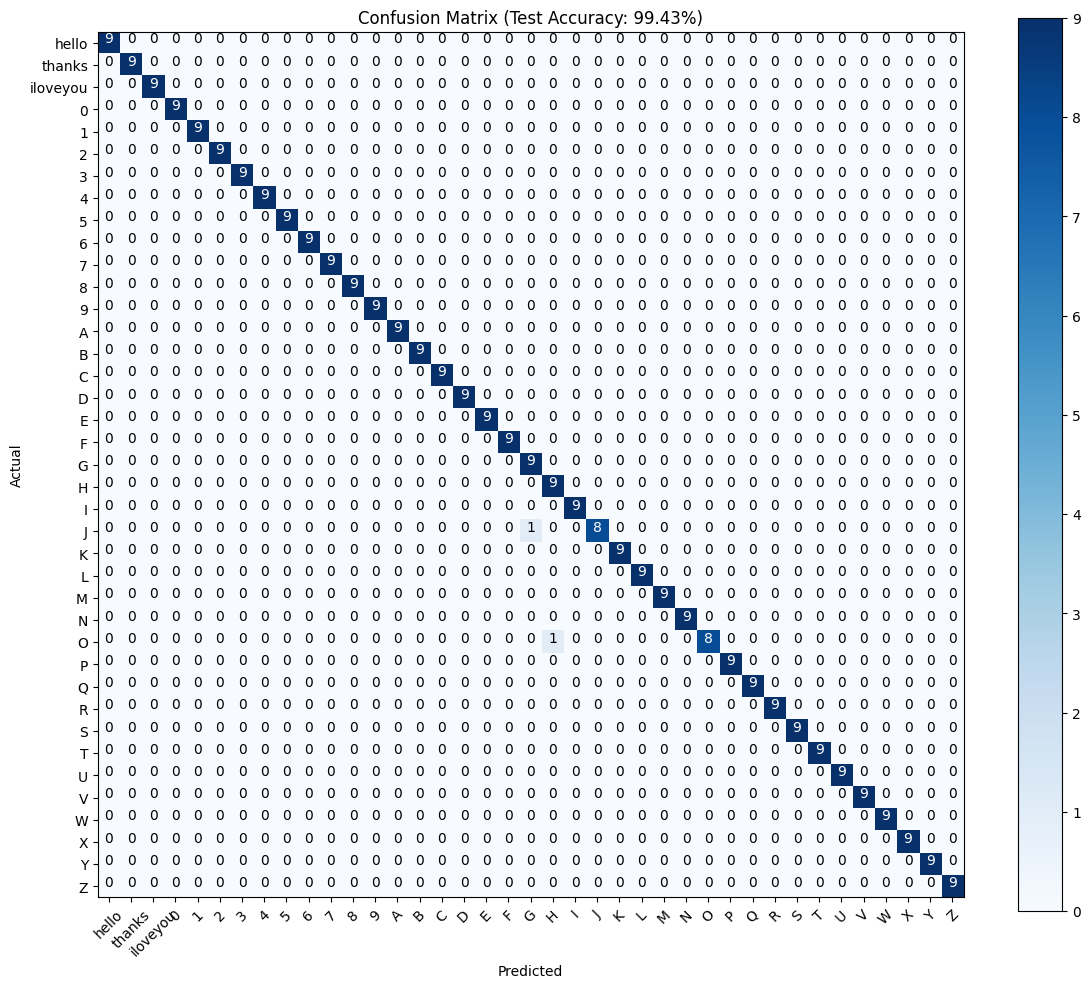

In [318]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
y_pred_train = model.predict(X_train, verbose=0)
y_pred_test = model.predict(X_test, verbose=0)

# Convert to class labels
y_train_classes = np.argmax(y_train, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
y_pred_train_classes = np.argmax(y_pred_train, axis=1)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)

# Calculate accuracies
train_accuracy = accuracy_score(y_train_classes, y_pred_train_classes)
test_accuracy = accuracy_score(y_test_classes, y_pred_test_classes)

print("=" * 50)
print("MODEL ACCURACY SUMMARY")
print("=" * 50)
print(f"Training Accuracy:   {train_accuracy:.2%} ({np.sum(y_train_classes == y_pred_train_classes)}/{len(y_train_classes)})")
print(f"Test Accuracy:       {test_accuracy:.2%} ({np.sum(y_test_classes == y_pred_test_classes)}/{len(y_test_classes)})")
print(f"Accuracy Gap:        {(train_accuracy - test_accuracy):.2%}")
print("=" * 50)

# Detailed classification report
print("\nCLASSIFICATION REPORT (TEST DATA):")
print("-" * 70)
print(classification_report(y_test_classes, y_pred_test_classes, target_names=actions))

# Confusion Matrix without seaborn
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test_classes, y_pred_test_classes)

# Create heatmap manually
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (Test Accuracy: {test_accuracy:.2%})')
plt.colorbar()

# Add labels
tick_marks = np.arange(len(actions))
plt.xticks(tick_marks, actions, rotation=45)
plt.yticks(tick_marks, actions)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

In [319]:
def print_model_summary(model, X_train, y_train, X_test, y_test, X_val=None, y_val=None):
    """
    Print comprehensive model summary with all metrics
    """
    import time
    from sklearn.metrics import accuracy_score
    
    print("\n" + "="*60)
    print("📊 MODEL PERFORMANCE SUMMARY")
    print("="*60)
    
    # 1. Data amounts
    print("\n📁 DATA SUMMARY:")
    print(f"   Total samples:     {len(X_train) + len(X_test) + (len(X_val) if X_val is not None else 0)}")
    print(f"   Training samples:  {len(X_train)} ({len(X_train)/(len(X_train)+len(X_test))*100:.1f}%)")
    if X_val is not None:
        print(f"   Validation samples: {len(X_val)}")
    print(f"   Test samples:      {len(X_test)} ({len(X_test)/(len(X_train)+len(X_test))*100:.1f}%)")
    print(f"   Sequence length:   {X_train.shape[1]} frames")
    print(f"   Features per frame: {X_train.shape[2]}")
    
    # 2. Inference time
    print("\n⚡ INFERENCE SPEED:")
    num_test = len(X_test)
    start = time.time()
    _ = model.predict(X_test[:min(100, num_test)], verbose=0)
    end = time.time()
    time_per_sample = (end - start) / min(100, num_test) * 1000
    print(f"   Avg inference time: {time_per_sample:.2f} ms per sample")
    print(f"   Theoretical FPS:    {1000/time_per_sample:.1f} frames/sec")
    
    # 3. Accuracies
    print("\n🎯 ACCURACY:")
    y_train_pred = model.predict(X_train, verbose=0)
    y_test_pred = model.predict(X_test, verbose=0)
    
    train_acc = accuracy_score(np.argmax(y_train, axis=1), np.argmax(y_train_pred, axis=1))
    test_acc = accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_test_pred, axis=1))
    
    print(f"   Training accuracy:  {train_acc:.2%}")
    print(f"   Test accuracy:      {test_acc:.2%}")
    print(f"   Overfitting gap:    {(train_acc - test_acc):.2%}")
    
    # 4. Model complexity
    print("\n🧠 MODEL COMPLEXITY:")
    print(f"   Total parameters:   {model.count_params():,}")
    print(f"   Model size:         {model.count_params() * 4 / 1024 / 1024:.2f} MB (float32)")
    
    print("\n" + "="*60)
    
    return {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'inference_time_ms': time_per_sample,
        'train_samples': len(X_train),
        'test_samples': len(X_test)
    }

# Run the summary
metrics = print_model_summary(model, X_train, y_train, X_test, y_test, X_val, y_val)


📊 MODEL PERFORMANCE SUMMARY

📁 DATA SUMMARY:
   Total samples:     2691
   Training samples:  1872 (84.2%)
   Validation samples: 468
   Test samples:      351 (15.8%)
   Sequence length:   30 frames
   Features per frame: 166

⚡ INFERENCE SPEED:
   Avg inference time: 1.62 ms per sample
   Theoretical FPS:    618.9 frames/sec

🎯 ACCURACY:
   Training accuracy:  99.84%
   Test accuracy:      99.43%
   Overfitting gap:    0.41%

🧠 MODEL COMPLEXITY:
   Total parameters:   6,686,503
   Model size:         25.51 MB (float32)



In [320]:
# Add to your real-time detection loop (around line where you do model.predict)
if len(sequence) == 30:
    # Time the prediction
    start_time = time.time()
    res = model.predict(np.expand_dims(sequence, axis=0), verbose=0)[0]
    inference_time = (time.time() - start_time) * 1000  # ms
    
    # Display on screen
    cv2.putText(image, f"Inf time: {inference_time:.1f} ms", (10, 60), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)
    
    # Optional: Calculate running average
    if 'times' not in locals():
        times = []
    times.append(inference_time)
    if len(times) > 30:
        times.pop(0)
    avg_time = sum(times) / len(times)
    cv2.putText(image, f"Avg: {avg_time:.1f} ms", (10, 80), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)

In [321]:
def diagnose_model_health(model, X_train, y_train, X_test, y_test, actions):
    print("🔍 MODEL HEALTH CHECK")
    print("=" * 50)
    
    # 1. Check train/test sizes
    print(f"\n📊 DATA SIZES:")
    print(f"  Train: {len(X_train)} samples")
    print(f"  Test:  {len(X_test)} samples")
    
    # 2. Check if test samples are unique
    test_set = set([tuple(x.flatten()) for x in X_test[:50]])  # First 50
    train_set = set([tuple(x.flatten()) for x in X_train[:500]])  # First 500
    overlap = len(test_set.intersection(train_set))
    print(f"\n🔄 DATA OVERLAP:")
    print(f"  Test samples overlapping with train: {overlap}/50")
    
    # 3. Check prediction confidence
    y_pred = model.predict(X_test, verbose=0)
    confidences = [np.max(pred) for pred in y_pred]
    avg_confidence = np.mean(confidences)
    print(f"\n📈 CONFIDENCE:")
    print(f"  Avg confidence on test: {avg_confidence:.4f}")
    print(f"  Min confidence: {np.min(confidences):.4f}")
    print(f"  Max confidence: {np.max(confidences):.4f}")
    
    if avg_confidence > 0.98:
        print("  ⚠️ Very high confidence - possible overfitting!")
    
    # 4. Check for near-perfect predictions
    perfect_predictions = sum(1 for conf in confidences if conf > 0.99)
    print(f"\n🎯 PERFECT PREDICTIONS:")
    print(f"  Predictions with >99% confidence: {perfect_predictions}/{len(confidences)}")
    
    # 5. Final verdict
    print("\n" + "=" * 50)
    if avg_confidence > 0.98 and perfect_predictions > len(confidences) * 0.9:
        print("❌ LIKELY PROBLEM: Model is overconfident")
        print("   Possible causes:")
        print("   - Test data is too similar to training data")
        print("   - Model has memorized the data (too complex for data size)")
        print("   - Data leakage (test samples in training)")
    else:
        print("✅ Model looks healthy")

# Run diagnosis
diagnose_model_health(model, X_train, y_train, X_test, y_test, actions)


🔍 MODEL HEALTH CHECK

📊 DATA SIZES:
  Train: 1872 samples
  Test:  351 samples

🔄 DATA OVERLAP:
  Test samples overlapping with train: 5/50

📈 CONFIDENCE:
  Avg confidence on test: 0.9958
  Min confidence: 0.4632
  Max confidence: 1.0000
  ⚠️ Very high confidence - possible overfitting!

🎯 PERFECT PREDICTIONS:
  Predictions with >99% confidence: 345/351

❌ LIKELY PROBLEM: Model is overconfident
   Possible causes:
   - Test data is too similar to training data
   - Model has memorized the data (too complex for data size)
   - Data leakage (test samples in training)
